Website Traffic Analysis

In [327]:
import zipfile
import os

zip_path = "/content/archive (3).zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print("Files inside the ZIP:")
    for file in zip_ref.namelist():
        print(file)

Files inside the ZIP:
traffic.csv


In [328]:
# Extract the dataset from the ZIP file

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/traffic_data")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [329]:
import pandas as pd

file_path = "/content/traffic_data/traffic.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (226278, 9)

Column names:
['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc', 'linkid']


In [330]:
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [331]:
# Check data types and missing values

print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
event      object
date       object
country    object
city       object
artist     object
album      object
track      object
isrc       object
linkid     object
dtype: object

Missing Values:
event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64


In [332]:
# Convert the date column to datetime format

df['date'] = pd.to_datetime(df['date'])

print("Date column converted successfully!")
print("Date type:", df['date'].dtype)

Date column converted successfully!
Date type: datetime64[ns]


In [333]:
# Check the different types of events

print("Event types:")
print(df['event'].value_counts())

Event types:
event
pageview    142015
click        55732
preview      28531
Name: count, dtype: int64


In [334]:
# Check the date range of the dataset

print("Start date:", df['date'].min())
print("End date:", df['date'].max())

Start date: 2021-08-19 00:00:00
End date: 2021-08-25 00:00:00


In [335]:
# Count events for each date

daily_events = df.groupby('date')['event'].count()

print("Daily event counts:")
print(daily_events)

Daily event counts:
date
2021-08-19    35361
2021-08-20    34112
2021-08-21    34083
2021-08-22    32633
2021-08-23    29808
2021-08-24    29834
2021-08-25    30447
Name: event, dtype: int64


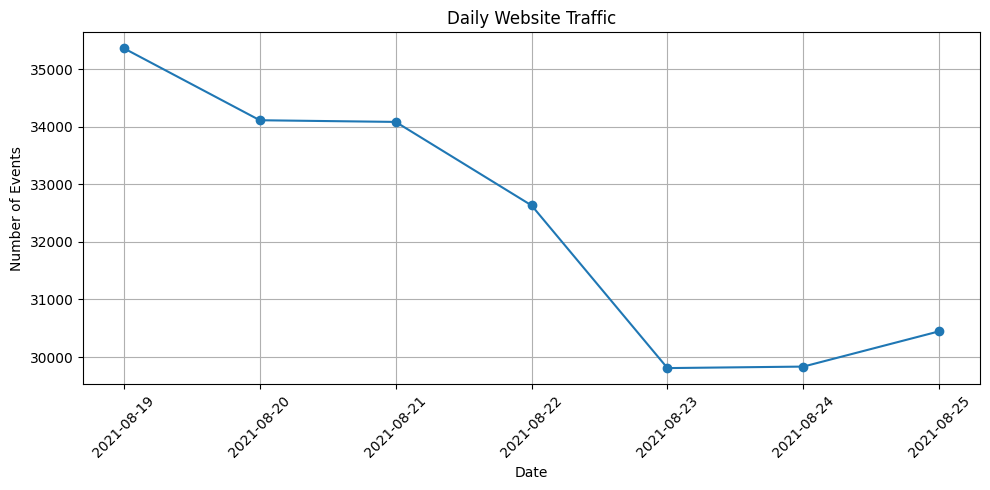

In [336]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(daily_events.index, daily_events.values, marker='o')

plt.title('Daily Website Traffic')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [337]:
# Check the number of unique link IDs

unique_linkids = df['linkid'].nunique()

print("Total records:", len(df))
print("Unique link IDs:", unique_linkids)

Total records: 226278
Unique link IDs: 3839


In [338]:
# Count each type of event

event_counts = df['event'].value_counts()

print("Event distribution:")
print(event_counts)

Event distribution:
event
pageview    142015
click        55732
preview      28531
Name: count, dtype: int64


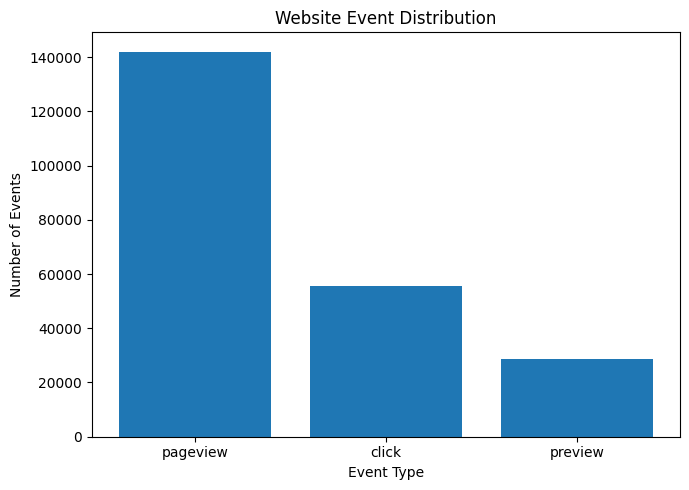

In [339]:
# Visualize event distribution

plt.figure(figsize=(7, 5))

plt.bar(event_counts.index, event_counts.values)

plt.title('Website Event Distribution')
plt.xlabel('Event Type')
plt.ylabel('Number of Events')

plt.tight_layout()
plt.show()

In [340]:
# Find the top 10 countries by number of events

country_traffic = df['country'].value_counts().head(10)

print("Top 10 countries by traffic:")
print(country_traffic)

Top 10 countries by traffic:
country
Saudi Arabia            47334
India                   42992
United States           32558
France                  15661
Iraq                     8260
United Kingdom           5970
Pakistan                 5644
Germany                  4794
United Arab Emirates     3702
Turkey                   3514
Name: count, dtype: int64


In [341]:
# Find the top 10 cities by number of events

city_traffic = df['city'].value_counts().head(10)

print("Top 10 cities by traffic:")
print(city_traffic)

Top 10 cities by traffic:
city
Jeddah         22791
Riyadh         17454
Unknown        16661
Hyderabad       3682
Dammam          3276
Erbil           3105
Kuwait City     3010
Lucknow         2808
Muscat          2717
Delhi           2567
Name: count, dtype: int64


In [342]:
# Calculate overall traffic metrics

total_events = len(df)
total_pageviews = (df['event'] == 'pageview').sum()
total_clicks = (df['event'] == 'click').sum()
total_previews = (df['event'] == 'preview').sum()

click_rate = (total_clicks / total_pageviews) * 100
preview_rate = (total_previews / total_pageviews) * 100

print("Traffic Metrics:")
print("Total Events:", total_events)
print("Total Pageviews:", total_pageviews)
print("Total Clicks:", total_clicks)
print("Total Previews:", total_previews)
print("Click Rate:", round(click_rate, 2), "%")
print("Preview Rate:", round(preview_rate, 2), "%")

Traffic Metrics:
Total Events: 226278
Total Pageviews: 142015
Total Clicks: 55732
Total Previews: 28531
Click Rate: 39.24 %
Preview Rate: 20.09 %


In [343]:
# Calculate event percentages

event_percentages = (event_counts / total_events * 100).round(2)

print("Event percentages:")
print(event_percentages)

Event percentages:
event
pageview    62.76
click       24.63
preview     12.61
Name: count, dtype: float64


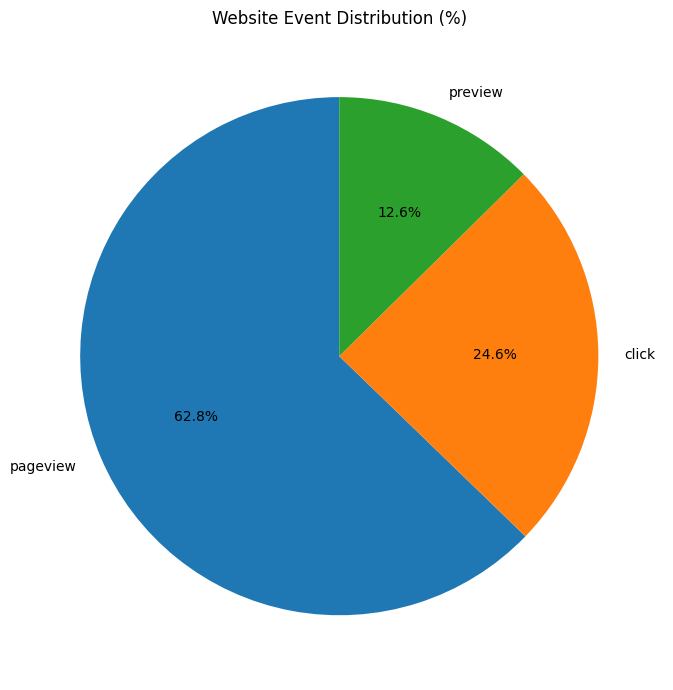

In [344]:
# Visualize event percentages

plt.figure(figsize=(7, 7))

plt.pie(
    event_percentages.values,
    labels=event_percentages.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Website Event Distribution (%)')

plt.tight_layout()
plt.show()

In [345]:
# Calculate basic summary statistics

print("Daily Traffic Statistics:")
print("Mean:", daily_events.mean())
print("Median:", daily_events.median())
print("Mode:", daily_events.mode().tolist())

print("\nEvent Mode:")
print("Most common event:", df['event'].mode()[0])

Daily Traffic Statistics:
Mean: 32325.428571428572
Median: 32633.0
Mode: [29808, 29834, 30447, 32633, 34083, 34112, 35361]

Event Mode:
Most common event: pageview


In [346]:
# Final check of missing values and data types

summary_check = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum()
})

print("Final Data Quality Summary:")
print(summary_check)

Final Data Quality Summary:
              Data Type  Missing Values
event            object               0
date     datetime64[ns]               0
country          object              11
city             object              11
artist           object              37
album            object               5
track            object               5
isrc             object            7121
linkid           object               0


# Conclusion and Key Insights

The website traffic analysis of `traffic.csv` shows **226,278 total events** recorded between **19 August 2021 and 25 August 2021**. Pageviews were the most common event with **142,015**, followed by **55,732 clicks** and **28,531 previews**.

The traffic was highest from **Saudi Arabia (47,334)** and **India (42,992)**. Among the identified cities, **Jeddah (22,791)** and **Riyadh (17,454)** recorded the highest traffic. The most active content link was **“Jalebi Baby” by Tesher**, with **40,841 events**.

### Actionable Insights

* **Promote popular content:** Analyze high-performing content such as “Jalebi Baby” and use successful content patterns to support future promotions.

* **Focus on high-traffic markets:** Saudi Arabia and India generated high levels of traffic, so targeted campaigns and localized content can be considered for these markets.

* **Improve data quality:** Missing values, especially the **7,121 missing ISRC values**, should be reduced through better data collection and validation.

### Final Conclusion

Overall, the analysis shows that website activity remained fairly consistent during the seven-day period, while traffic varied across countries, cities, and content. These findings can help Alfido Tech understand traffic patterns, identify popular content, and improve future data-driven decisions.